In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import seaborn as sns
from plotly.subplots import make_subplots

from utils.figures_utils import *


In [2]:
sns.set_theme(style="whitegrid")

TOOL_ORDER = [
    "methylseg_wgbs",
    "methylseg_hm450k",
    "methylseekr",
    "dnmtools",
    "dnmtools_array",
    "dnmtools_pmr",
    "mmseekr",
    "methylasso",
]

TOOL_LABELS = {
    "methylseg_wgbs": "MethylSeg WGBS",
    "methylseg_hm450k": "MethylSeg HM450K",
    "methylseekr": "MethylSeekR",
    "dnmtools": "DNMTools WGBS",
    "dnmtools_array": "DNMTools Array",
    "dnmtools_pmr": "DNMTools PMR",
    "mmseekr": "MMSeekR",
    "methylasso": "MethylLasso",
}

RESOLUTION_MAP = {
    "methylseg_wgbs": "WGBS",
    "methylseg_hm450k": "HM450K",
    "methylseekr": "WGBS",
    "dnmtools": "WGBS",
    "dnmtools_array": "HM450K",
    "dnmtools_pmr": "WGBS",
    "mmseekr": "WGBS",
    "methylasso": "WGBS",
}

RUN_TOOL_NAME_MAP = {
    "DNMTools_Array_PMD": "dnmtools_array",
    "DNMTools_PMD": "dnmtools",
    "DNMTools_PMR": "dnmtools_pmr",
    "MethylSeekR": "methylseekr",
    "MethylSeg_HM450K": "methylseg_hm450k",
    "MethylSeg_WGBS": "methylseg_wgbs",
    "methylasso": "methylasso",
    "mmseekr": "mmseekr",
}

REGION_TOOL_NAME_MAP = {
    "dnmtools": "dnmtools",
    "dnmtools_array": "dnmtools_array",
    "dnmtools_pmr": "dnmtools_pmr",
    "methylasso": "methylasso",
    "methylseekr": "methylseekr",
    "methylseg_hm450k": "methylseg_hm450k",
    "methylseg_wgbs": "methylseg_wgbs",
    "mmseekr": "mmseekr",
}

FIGSIZE_MEMORY = (11, 6)
FIGSIZE_RUNTIME = (11, 6)
FIGSIZE_PMD = (16, 6)
DPI = 300

MEMORY_TITLE = "Peak Memory Usage Across Region Calling Tools"
RUNTIME_TITLE = "Runtime Across Region Calling Tools"
TABLE_TITLE = "Region Calling Summary by Tool"
PMD_METH_TITLE = "Average Methylation by Tool"
PMD_INTERMEDIATE_TITLE = "Intermediate CpGs by Tool"

SAVE_FIGURES = False
SAVE_DIR = OUT_DIR / "region_calling_figures"


In [3]:
def normalize_run_tool_name(tool_name: str) -> str:
    return RUN_TOOL_NAME_MAP.get(str(tool_name), str(tool_name))


def normalize_region_tool_name(tool_name: str) -> str:
    return REGION_TOOL_NAME_MAP.get(str(tool_name), str(tool_name))


def ordered_tool_labels() -> list[str]:
    return [TOOL_LABELS[tool] for tool in TOOL_ORDER]


def apply_tool_order(df: pd.DataFrame, tool_col: str = "tool_normalized") -> pd.DataFrame:
    out_df = df.copy()
    out_df[tool_col] = pd.Categorical(out_df[tool_col], categories=TOOL_ORDER, ordered=True)
    out_df = out_df.dropna(subset=[tool_col]).sort_values(tool_col).reset_index(drop=True)
    return out_df


def add_tool_labels(df: pd.DataFrame, tool_col: str = "tool_normalized") -> pd.DataFrame:
    out_df = df.copy()
    out_df["tool_label"] = out_df[tool_col].map(TOOL_LABELS)
    out_df["tool_label"] = pd.Categorical(
        out_df["tool_label"],
        categories=ordered_tool_labels(),
        ordered=True,
    )
    return out_df


def savefig_if_enabled(fig: plt.Figure, filename: str) -> None:
    if not SAVE_FIGURES:
        return
    SAVE_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(SAVE_DIR / filename, dpi=DPI, bbox_inches="tight")


In [4]:
sample_id = wgbs_cancer_samples()[-1]
methyl_seg_only = True


In [5]:
run_stats_df = get_run_stats_df().copy()
run_stats_df["tool_normalized"] = run_stats_df["tool_name"].map(normalize_run_tool_name)
run_stats_df["mem_peak_gb"] = pd.to_numeric(run_stats_df["mem_peak_mb"], errors="coerce") / 1024.0
run_stats_df["runtime_min"] = pd.to_numeric(run_stats_df["runtime_sec"], errors="coerce") / 60.0
run_stats_df = apply_tool_order(run_stats_df)
run_stats_df = add_tool_labels(run_stats_df)

run_stats_summary_df = (
    run_stats_df.groupby("tool_normalized", observed=True)
    .agg(
        n_samples=("sample_id", "nunique"),
        avg_mem_peak_gb=("mem_peak_gb", "mean"),
        avg_runtime_min=("runtime_min", "mean"),
    )
    .reset_index()
)
run_stats_summary_df["Resolution"] = run_stats_summary_df["tool_normalized"].map(RESOLUTION_MAP)
run_stats_summary_df["Tool"] = run_stats_summary_df["tool_normalized"].map(TOOL_LABELS)
run_stats_summary_df = run_stats_summary_df[[
    "Tool",
    "Resolution",
    "avg_mem_peak_gb",
    "avg_runtime_min",
]].rename(columns={
    "avg_mem_peak_gb": "Avg Peak Memory (GB)",
    "avg_runtime_min": "Avg Runtime (min)",
})
run_stats_summary_df = run_stats_summary_df.round({
    "Avg Peak Memory (GB)": 2,
    "Avg Runtime (min)": 2,
})

run_stats_summary_fig = plot_summary_table(
    run_stats_summary_df,
    "Aggregate Run Stats Across Samples",
)
run_stats_summary_fig


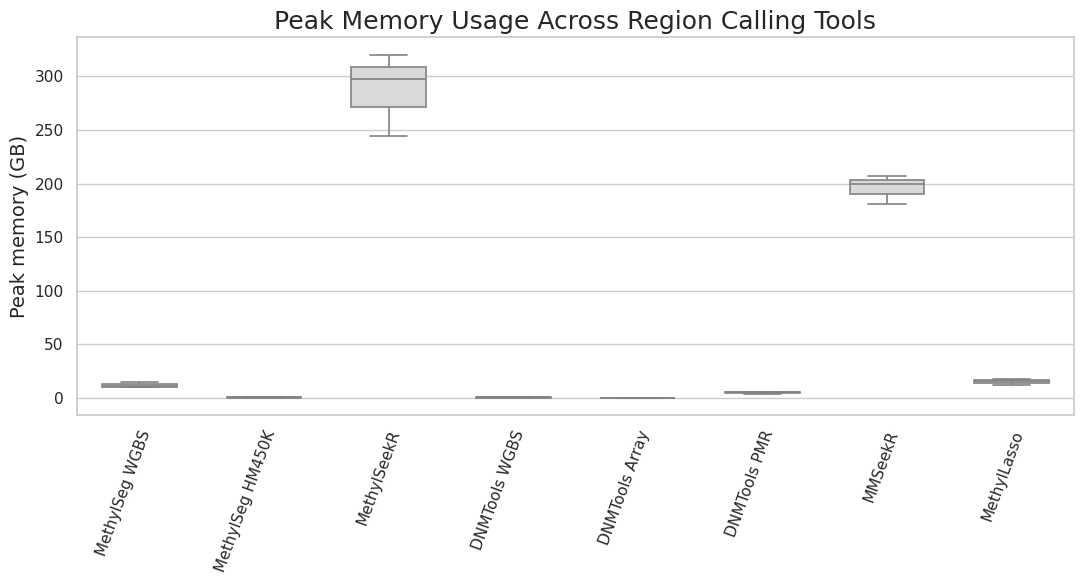

In [6]:
fig, ax = plt.subplots(figsize=FIGSIZE_MEMORY)
draw_boxplot(ax, run_stats_df, "mem_peak_gb", MEMORY_TITLE, "Peak memory (GB)")
fig.tight_layout()
savefig_if_enabled(fig, "memory_box.png")
plt.show()


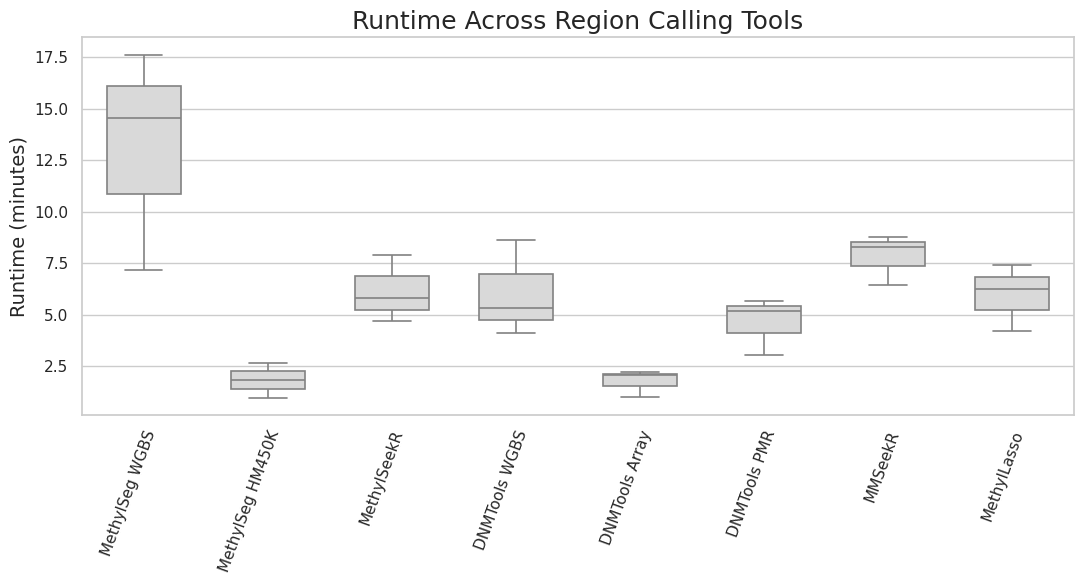

In [7]:
fig, ax = plt.subplots(figsize=FIGSIZE_RUNTIME)
draw_boxplot(ax, run_stats_df, "runtime_min", RUNTIME_TITLE, "Runtime (minutes)")
fig.tight_layout()
savefig_if_enabled(fig, "runtime_box.png")
plt.show()


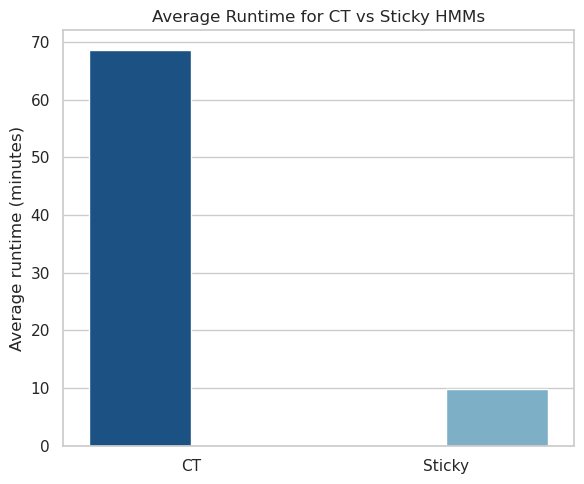

In [8]:
from colors import HEATMAP_COLOR_SCALES, NEUTRAL_COLORS, TOOL_HIGHLIGHT_COLORS

hmm_run_times_df = get_hmm_run_times_df().copy()
hmm_run_times_df["runtime_min"] = pd.to_numeric(hmm_run_times_df["runtime_sec"], errors="coerce") / 60.0
hmm_run_times_df["hmm_label"] = hmm_run_times_df["hmm_type"].map({
    "ct": "CT",
    "sticky": "Sticky",
})
hmm_run_times_df["hmm_label"] = pd.Categorical(
    hmm_run_times_df["hmm_label"],
    categories=["CT", "Sticky"],
    ordered=True,
)

hmm_runtime_pivot_df = (
    hmm_run_times_df.pivot_table(
        index="sample_id",
        columns="hmm_type",
        values="runtime_sec",
        aggfunc="first",
    )
    .dropna(subset=["ct", "sticky"])
    .reset_index()
)
hmm_runtime_pivot_df = hmm_runtime_pivot_df[hmm_runtime_pivot_df["ct"] > 0].copy()
hmm_runtime_pivot_df["ct_runtime_min"] = hmm_runtime_pivot_df["ct"] / 60.0
hmm_runtime_pivot_df["sticky_runtime_min"] = hmm_runtime_pivot_df["sticky"] / 60.0
hmm_runtime_pivot_df["ct_over_sticky"] = hmm_runtime_pivot_df["ct"] / hmm_runtime_pivot_df["sticky"]
hmm_runtime_pivot_df = hmm_runtime_pivot_df.sort_values("ct_over_sticky", ascending=False).reset_index(drop=True)

multiplier_tick_candidates = np.array([0.25, 0.5, 1, 2, 5, 10, 20, 50, 100], dtype=float)
multiplier_ticks = multiplier_tick_candidates[
    (multiplier_tick_candidates >= hmm_runtime_pivot_df["ct_over_sticky"].min() * 0.8)
    & (multiplier_tick_candidates <= hmm_runtime_pivot_df["ct_over_sticky"].max() * 1.25)
]
if multiplier_ticks.size == 0:
    multiplier_ticks = np.array([1.0])
if 1.0 not in multiplier_ticks:
    multiplier_ticks = np.sort(np.unique(np.append(multiplier_ticks, 1.0)))

fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(
    data=hmm_run_times_df,
    x="hmm_label",
    y="runtime_min",
    hue="hmm_label",
    order=["CT", "Sticky"],
    hue_order=["CT", "Sticky"],
    estimator=np.mean,
    errorbar=None,
    palette=[TOOL_HIGHLIGHT_COLORS["MethylSeg WGBS"], TOOL_HIGHLIGHT_COLORS["MethylSeg HM450K"]],
    legend=False,
    ax=ax,
)
ax.set_title("Average Runtime for CT vs Sticky HMMs")
ax.set_xlabel("")
ax.set_ylabel("Average runtime (minutes)")
fig.tight_layout()
savefig_if_enabled(fig, "hmm_runtime_bar.png")
plt.show()


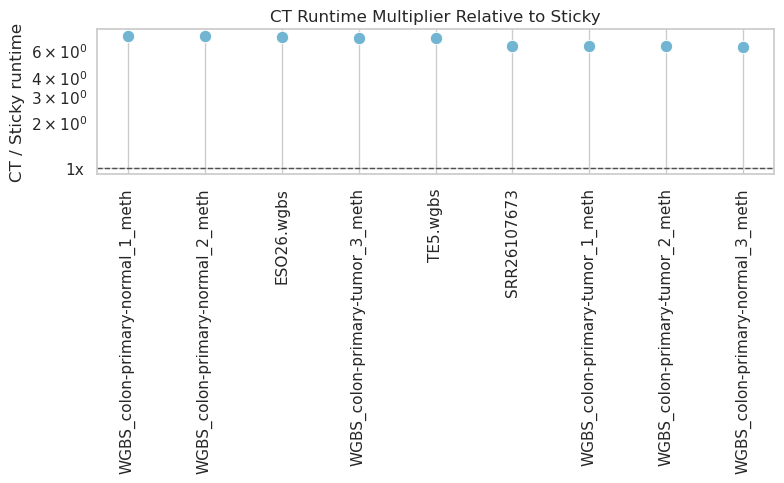

In [9]:
fig, ax = plt.subplots(figsize=(max(8, 0.35 * len(hmm_runtime_pivot_df) + 2), 5))
sns.scatterplot(
    data=hmm_runtime_pivot_df,
    x="sample_id",
    y="ct_over_sticky",
    color=TOOL_HIGHLIGHT_COLORS["MethylSeg HM450K"],
    s=80,
    ax=ax,
)
ax.axhline(1.0, color=NEUTRAL_COLORS["axis_gray"], linestyle="--", linewidth=1)
ax.set_yscale("log")
ax.set_yticks(multiplier_ticks)
ax.set_yticklabels([f"{tick:g}x" for tick in multiplier_ticks])
ax.set_title("CT Runtime Multiplier Relative to Sticky")
ax.set_xlabel("")
ax.set_ylabel("CT / Sticky runtime")
ax.tick_params(axis="x", rotation=90)
fig.tight_layout()
savefig_if_enabled(fig, "hmm_runtime_multiplier_scatter.png")
plt.show()


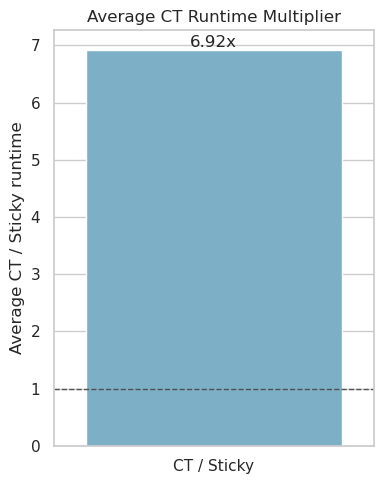

In [10]:
avg_multiplier_df = pd.DataFrame({
    "metric": ["CT / Sticky"],
    "avg_multiplier": [hmm_runtime_pivot_df["ct_over_sticky"].mean()],
})

fig, ax = plt.subplots(figsize=(4, 5))
sns.barplot(
    data=avg_multiplier_df,
    x="metric",
    y="avg_multiplier",
    color=TOOL_HIGHLIGHT_COLORS["MethylSeg HM450K"],
    ax=ax,
)
ax.axhline(1.0, color=NEUTRAL_COLORS["axis_gray"], linestyle="--", linewidth=1)
ax.set_title("Average CT Runtime Multiplier")
ax.set_xlabel("")
ax.set_ylabel("Average CT / Sticky runtime")
ax.text(
    0,
    avg_multiplier_df.loc[0, "avg_multiplier"],
    f'{avg_multiplier_df.loc[0, "avg_multiplier"]:.2f}x',
    ha="center",
    va="bottom",
)
fig.tight_layout()
savefig_if_enabled(fig, "hmm_runtime_multiplier_bar.png")
plt.show()


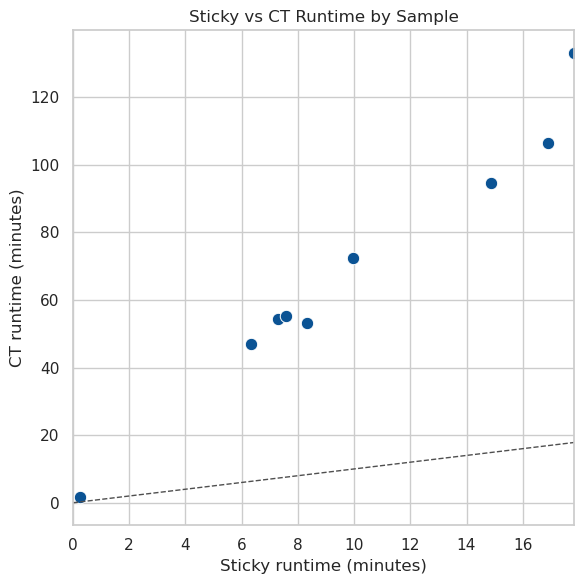

In [11]:
sticky_runtime_max_min = hmm_runtime_pivot_df["sticky_runtime_min"].max()

fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(
    data=hmm_runtime_pivot_df,
    x="sticky_runtime_min",
    y="ct_runtime_min",
    color=TOOL_HIGHLIGHT_COLORS["MethylSeg WGBS"],
    s=80,
    ax=ax,
)
ax.plot([0, sticky_runtime_max_min], [0, sticky_runtime_max_min], linestyle="--", color=NEUTRAL_COLORS["axis_gray"], linewidth=1)
ax.set_xlim(0, sticky_runtime_max_min)
ax.set_title("Sticky vs CT Runtime by Sample")
ax.set_xlabel("Sticky runtime (minutes)")
ax.set_ylabel("CT runtime (minutes)")
fig.tight_layout()
savefig_if_enabled(fig, "hmm_runtime_sticky_vs_ct_scatter.png")
plt.show()


In [12]:
region_stats_df = get_region_stats_df().copy()
region_stats_df["tool_normalized"] = region_stats_df["tool"].map(normalize_region_tool_name)
region_stats_df = apply_tool_order(region_stats_df)

summary_table_df = (
    region_stats_df.groupby("tool_normalized", observed=True)
    .agg(
        avg_total_regions_called=("n_regions", "mean"),
        avg_median_region_length=("median_length", "mean"),
        avg_genome_coverage_pct=("genome_coverage_pct", "mean"),
    )
    .reset_index()
)
summary_table_df["Resolution"] = summary_table_df["tool_normalized"].map(RESOLUTION_MAP)
summary_table_df["Tool"] = summary_table_df["tool_normalized"].map(TOOL_LABELS)
summary_table_df = summary_table_df[[
    "Tool",
    "Resolution",
    "avg_total_regions_called",
    "avg_median_region_length",
    "avg_genome_coverage_pct",
]].rename(columns={
    "avg_total_regions_called": "Avg Total Regions Called",
    "avg_median_region_length": "Avg Median Region Length",
    "avg_genome_coverage_pct": "Avg Genome Coverage (%)",
})
summary_table_df = summary_table_df.round({
    "Avg Total Regions Called": 1,
    "Avg Median Region Length": 1,
    "Avg Genome Coverage (%)": 2,
})

summary_table_fig = plot_summary_table(summary_table_df, TABLE_TITLE)
summary_table_fig


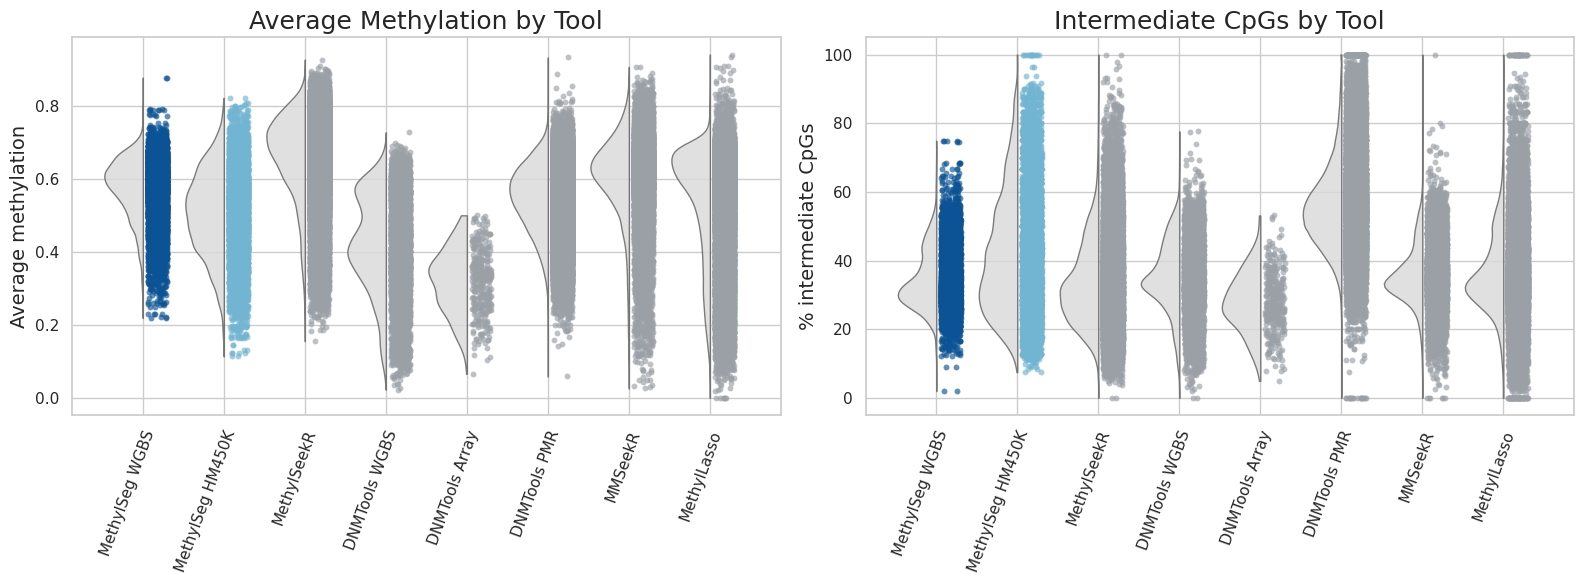

In [13]:
region_context_df = get_region_context_df().copy()
region_context_df["tool_normalized"] = region_context_df["tool"].map(normalize_region_tool_name)
region_context_df = apply_tool_order(region_context_df)
region_context_df = add_tool_labels(region_context_df)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_PMD, sharex=True)

draw_violin_with_points(axes[0], region_context_df, "mean_meth", PMD_METH_TITLE, "Average methylation")

draw_violin_with_points(axes[1], region_context_df, "pct_intermediate", PMD_INTERMEDIATE_TITLE, "% intermediate CpGs")

fig.tight_layout()
savefig_if_enabled(fig, "pmd_methylation_intermediate_violins.png")
plt.show()


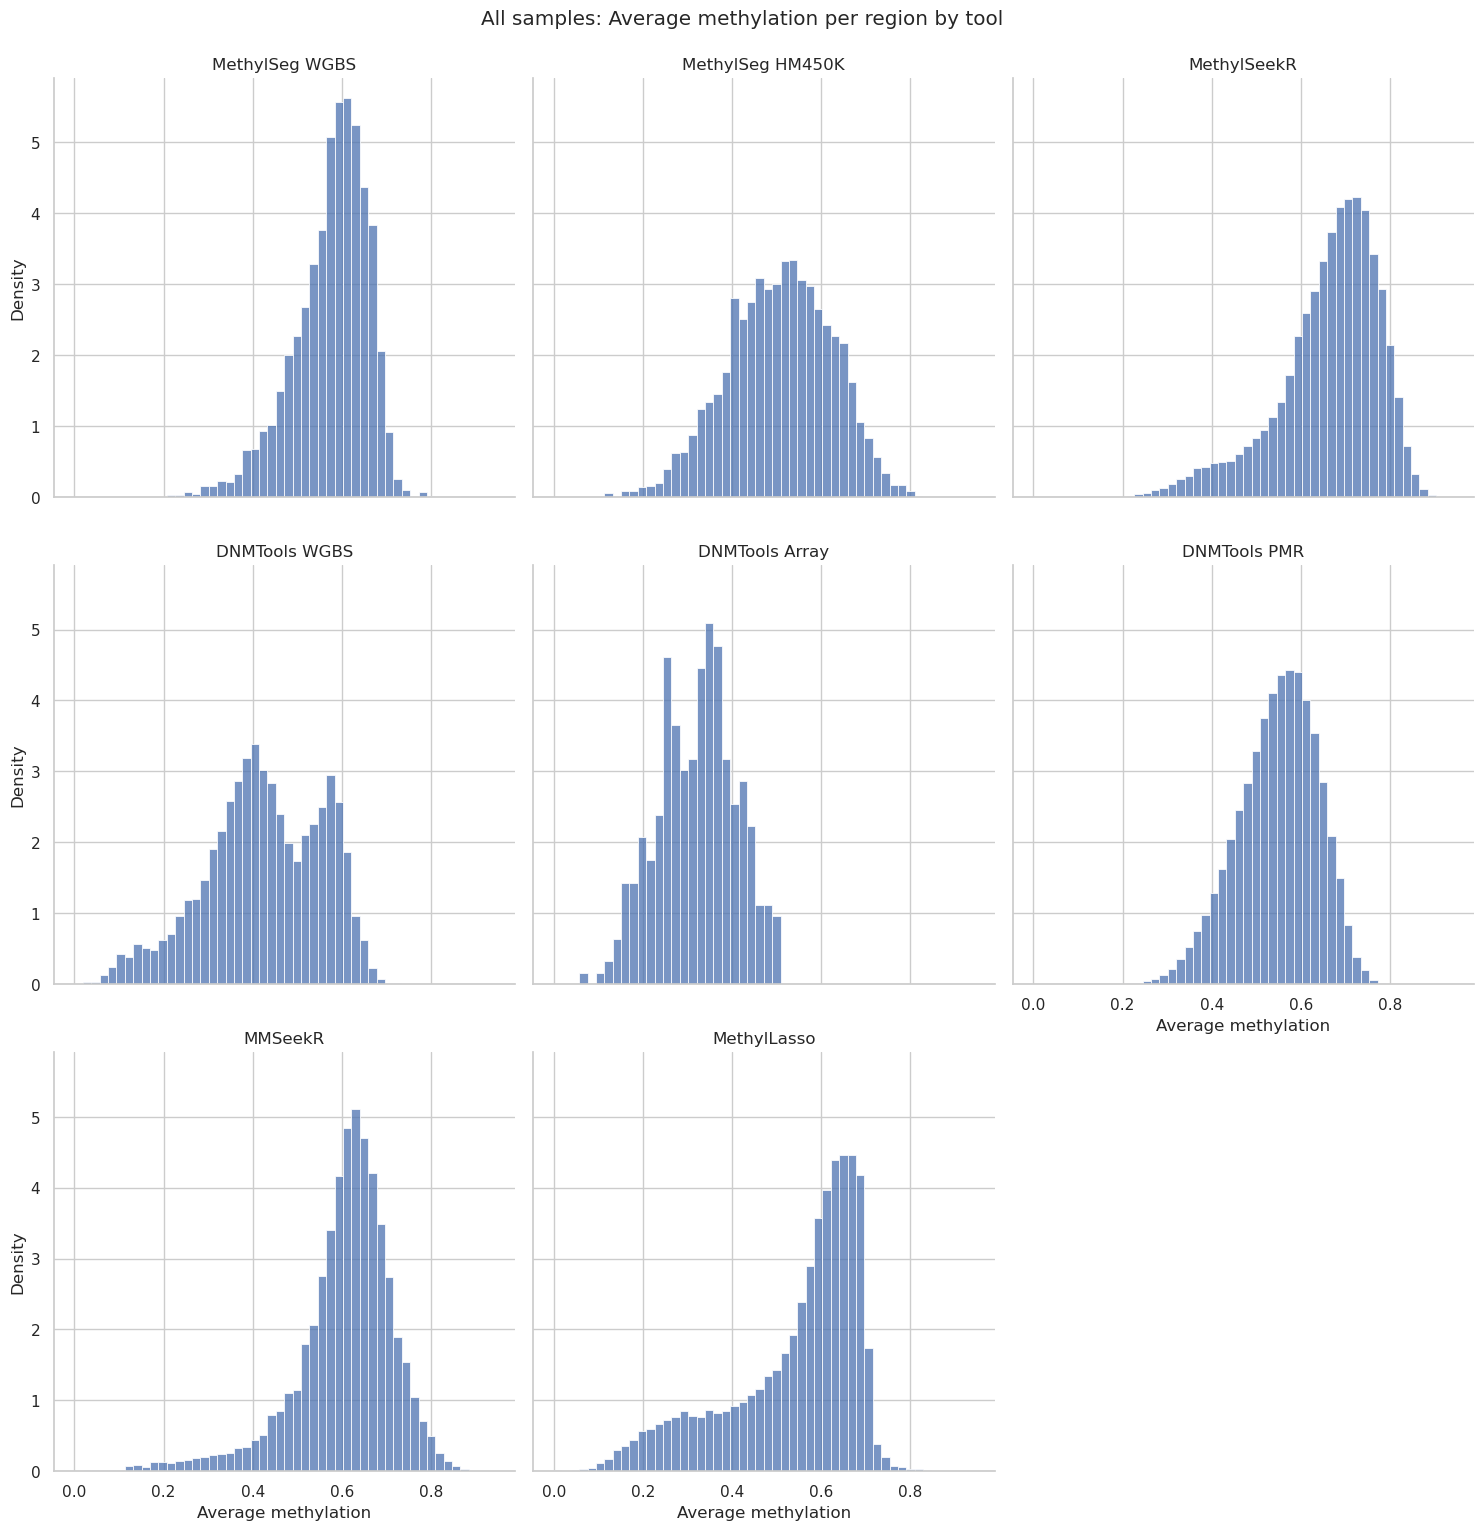

In [14]:
avg_meth_grid = plot_avg_methylation_hist()
avg_meth_grid


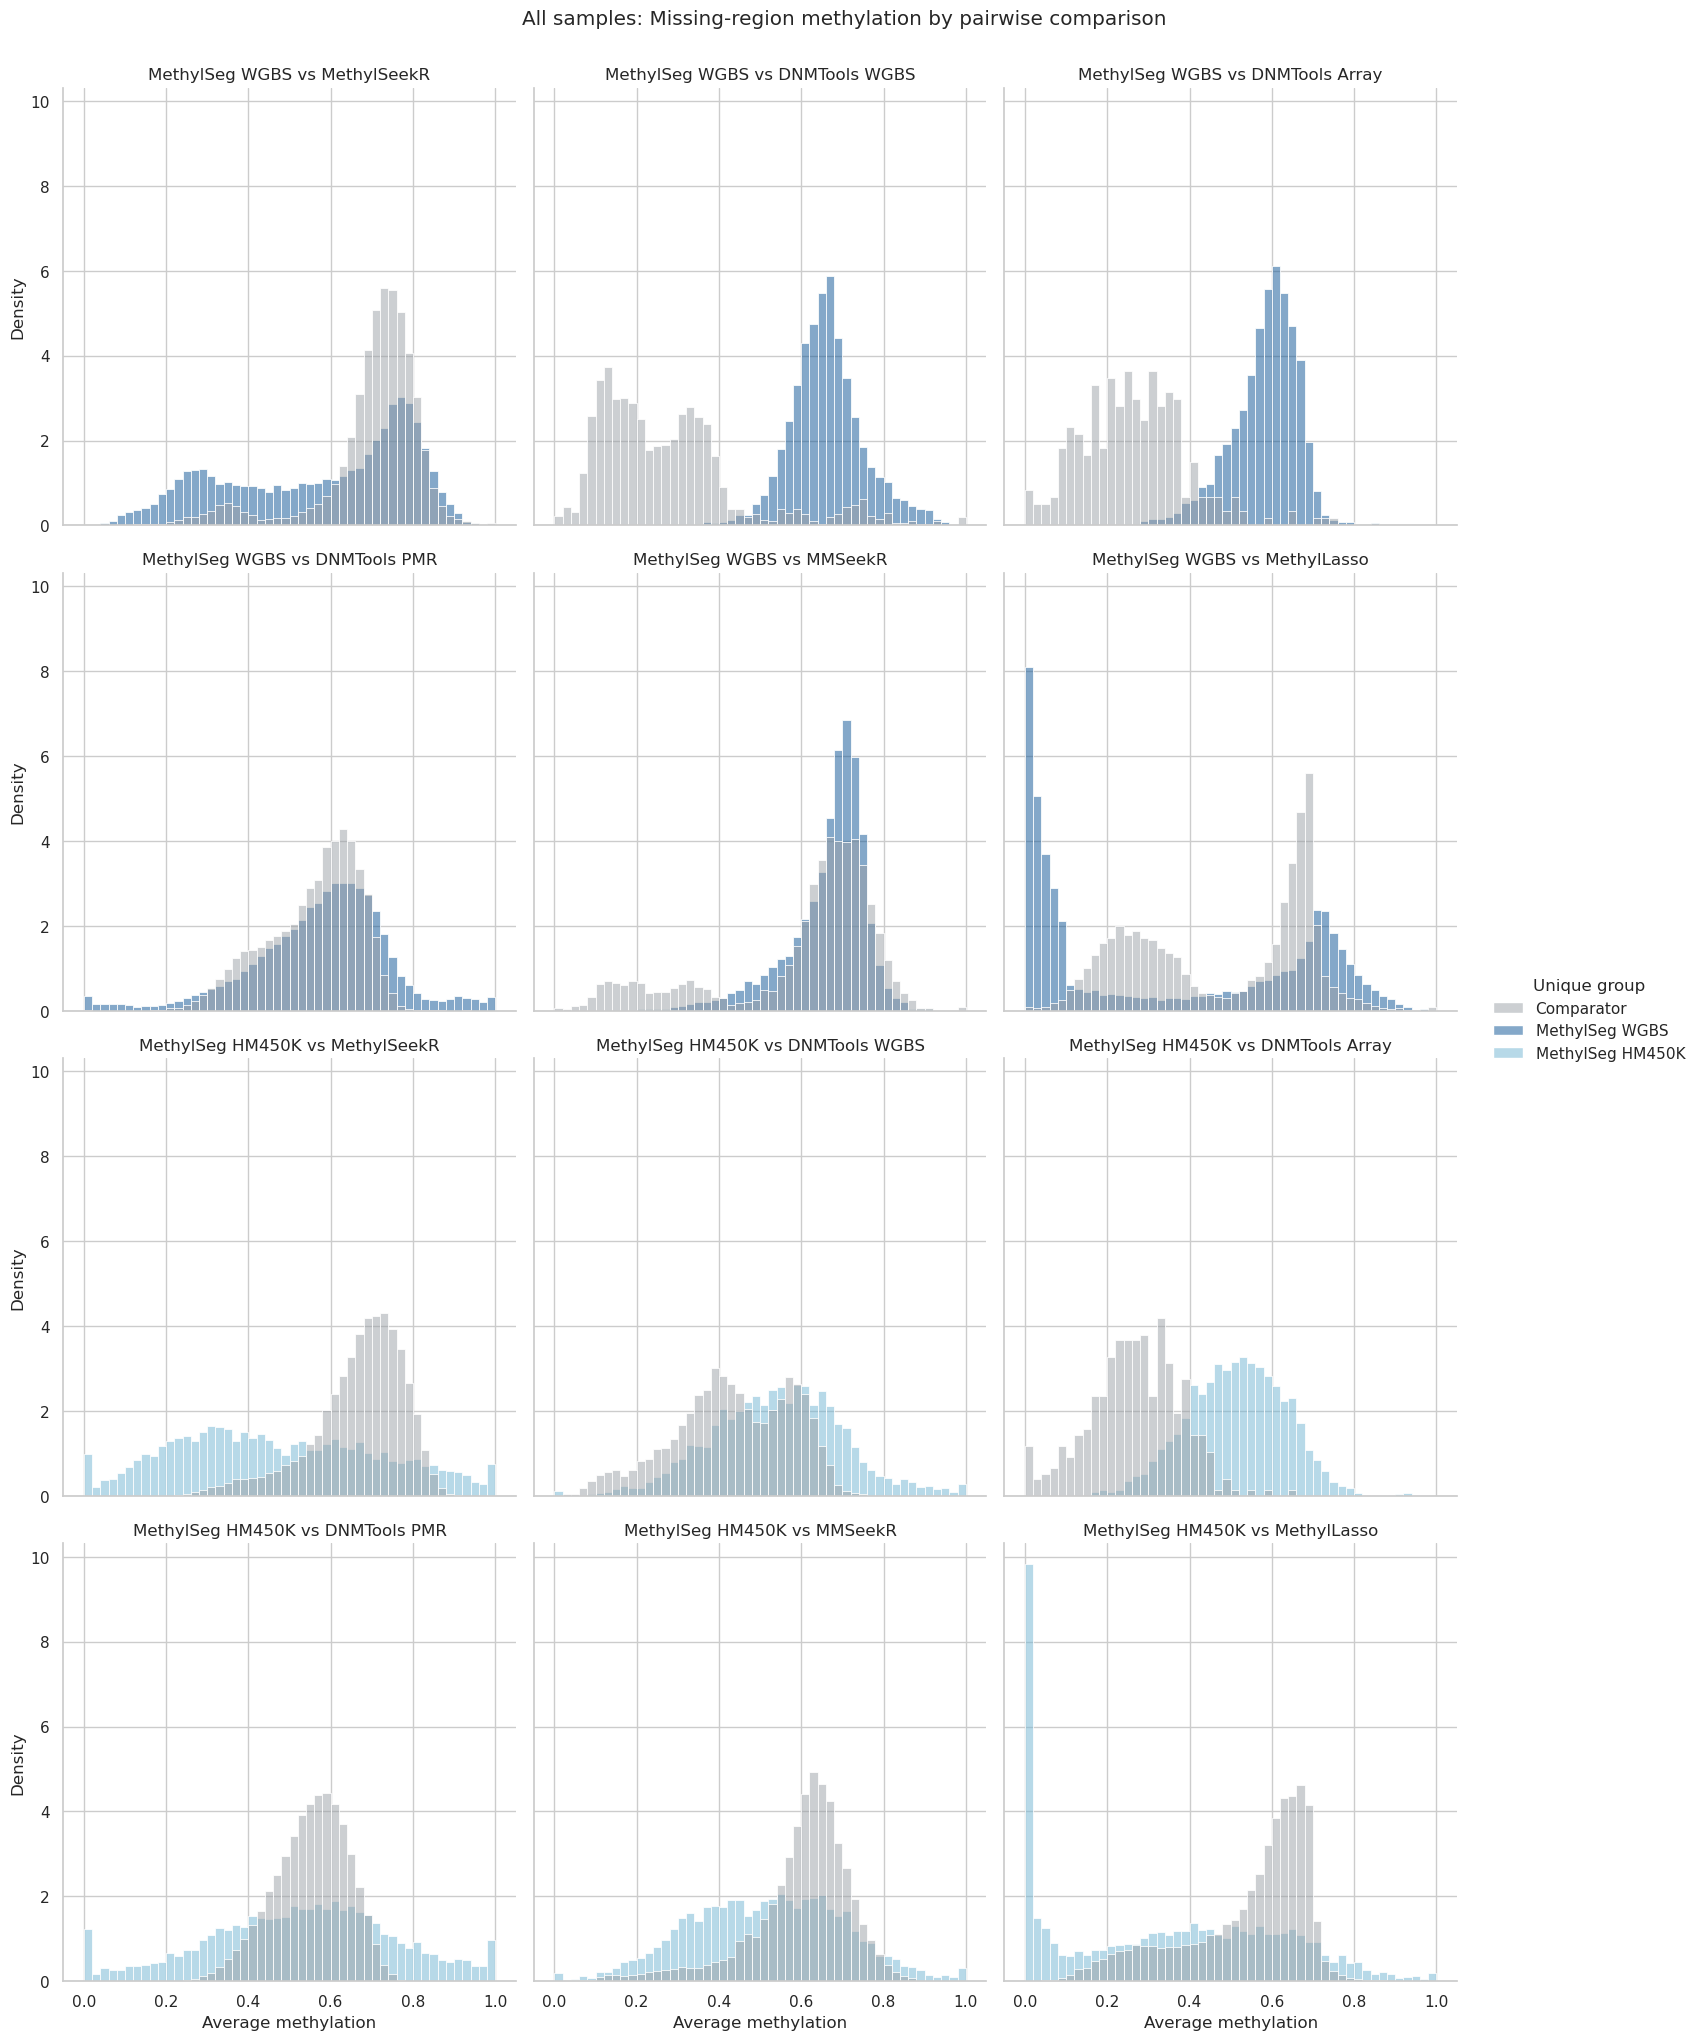

In [15]:
pairwise_missing_grid = plot_pairwise_missing(
    methyl_seg_only=methyl_seg_only,
)
pairwise_missing_grid


In [16]:
jaccard_matrix = load_jaccard_matrix(sample_id)
pct_covered_matrix = load_pct_cover_matrix(sample_id)

In [17]:
COMPARISON_TOOL_LABELS = {
    "methylseg": "MethylSeg WGBS",
    "methylseg_wgbs": "MethylSeg WGBS",
    "methylseg_hm450k": "MethylSeg HM450K",
    "methylseekr": "MethylSeekR",
    "dnmtools": "DNMTools WGBS",
    "dnmtools_array": "DNMTools Array",
    "dnmtools_pmr": "DNMTools PMR",
    "mmseekr": "MMSeekR",
    "methyl_lasso": "MethylLasso",
    "methylasso": "MethylLasso",
}

ARRAY_MODE_TOOLS = ["methylseg_hm450k", "dnmtools_array"]
BOLD_HEATMAP_LABELS = {"MethylSeg WGBS", "MethylSeg HM450K"}

def reorder_comparison_matrix(matrix_df: pd.DataFrame) -> pd.DataFrame:
    ordered_tools = [tool for tool in matrix_df.index if tool not in ARRAY_MODE_TOOLS]
    ordered_tools.extend(tool for tool in ARRAY_MODE_TOOLS if tool in matrix_df.index)
    return matrix_df.loc[ordered_tools, ordered_tools]

def relabel_comparison_matrix(matrix_df: pd.DataFrame) -> pd.DataFrame:
    display_df = matrix_df.copy()
    display_labels = [COMPARISON_TOOL_LABELS.get(tool, tool) for tool in display_df.index]
    display_df.index = display_labels
    display_df.columns = display_labels
    return display_df

plot_jaccard_matrix = relabel_comparison_matrix(reorder_comparison_matrix(jaccard_matrix)).round(4)
plot_pct_covered_matrix = relabel_comparison_matrix(
    reorder_comparison_matrix((pct_covered_matrix * 100.0).round(4))
)
plot_pct_not_covered_matrix = (100.0 - plot_pct_covered_matrix).round(4)

white_blue = HEATMAP_COLOR_SCALES["white_to_blue"]

heatmap_names = plot_jaccard_matrix.index.tolist()
heatmap_tick_labels = [
    f"<b>{label}</b>" if label in BOLD_HEATMAP_LABELS else label
    for label in heatmap_names
]

fig = make_subplots(
    rows=3,
    cols=1,
    subplot_titles=(
        "Percent of A covered by B (%)",
        "Percent of A NOT covered by B (%)",
        "Jaccard index (intersection / union)",
    ),
)

fig.add_trace(
    go.Heatmap(
        z=plot_pct_covered_matrix.values,
        x=heatmap_names,
        y=heatmap_names,
        zmin=0,
        zmax=100,
        colorscale=white_blue,
        colorbar=dict(title="% covered", lenmode="fraction", len=0.25, y=0.85),
        hovertemplate="A: %{y}<br>B: %{x}<br>% covered: %{z:.2f}%<extra></extra>",
    ),
    row=1,
    col=1,
)

fig.add_trace(
    go.Heatmap(
        z=plot_pct_not_covered_matrix.values,
        x=heatmap_names,
        y=heatmap_names,
        zmin=0,
        zmax=100,
        colorscale=white_blue,
        colorbar=dict(title="% not covered", lenmode="fraction", len=0.25, y=0.52),
        hovertemplate="A: %{y}<br>B: %{x}<br>% not covered: %{z:.2f}%<extra></extra>",
    ),
    row=2,
    col=1,
)

fig.add_trace(
    go.Heatmap(
        z=plot_jaccard_matrix.values,
        x=heatmap_names,
        y=heatmap_names,
        zmin=0,
        zmax=1,
        colorscale=white_blue,
        colorbar=dict(title="Jaccard", lenmode="fraction", len=0.25, y=0.19),
        hovertemplate="A: %{y}<br>B: %{x}<br>Jaccard: %{z:.4f}<extra></extra>",
    ),
    row=3,
    col=1,
)

fig.update_layout(
    height=1200,
    width=1000,
    title_text=f"{sample_id} Pairwise bed comparisons",
    template="plotly_white",
    margin=dict(l=120, r=40, t=100, b=80),
)

fig.update_yaxes(
    autorange="reversed",
    tickmode="array",
    tickvals=heatmap_names,
    ticktext=heatmap_tick_labels,
)
fig.update_xaxes(
    tickangle=45,
    tickmode="array",
    tickvals=heatmap_names,
    ticktext=heatmap_tick_labels,
)

fig.show()

In [18]:
IGV_EXPORT_ROOT = OUT_DIR / "region_calling_figures" / "igv_exports"
IGV_EXPORT_SAMPLES = wgbs_cancer_samples()
IGV_REGION_TOOLS = igv_export_tool_slugs()

EXPORT_WGBS_BIGWIG = True
EXPORT_HM450K_BIGWIG = True
EXPORT_REGION_BEDS = True

IGV_EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

In [19]:
igv_export_summaries = []

for sample_id in IGV_EXPORT_SAMPLES:
    summary = export_sample_igv_tracks(
        sample_id,
        IGV_EXPORT_ROOT,
        export_wgbs_bigwig=EXPORT_WGBS_BIGWIG,
        export_hm450k_bigwig=EXPORT_HM450K_BIGWIG,
        export_region_beds=EXPORT_REGION_BEDS,
        region_tools=IGV_REGION_TOOLS,
    )
    igv_export_summaries.append(summary)

    print(
        f"{sample_id} ({summary['genome']}): "
        f"{len(summary['methylation_paths'])} methylation tracks, "
        f"{len(summary['region_paths'])} region tracks"
    )
    if summary["methylation_paths"]:
        print(f"  methylation dir: {Path(summary['methylation_paths'][0]).parent}")
    if summary["region_paths"]:
        print(f"  regions dir: {Path(summary['region_paths'][0]).parent}")

pd.DataFrame(
    {
        "sample_id": [summary["sample_id"] for summary in igv_export_summaries],
        "genome": [summary["genome"] for summary in igv_export_summaries],
        "n_methylation_tracks": [len(summary["methylation_paths"]) for summary in igv_export_summaries],
        "n_region_tracks": [len(summary["region_paths"]) for summary in igv_export_summaries],
    }
)

ESO26.wgbs (hg38): 2 methylation tracks, 8 region tracks
  methylation dir: /uufs/chpc.utah.edu/common/home/u0914269/clement/projects/20260624_methylseg/figures/out/region_calling_figures/igv_exports/ESO26.wgbs/methylation
  regions dir: /uufs/chpc.utah.edu/common/home/u0914269/clement/projects/20260624_methylseg/figures/out/region_calling_figures/igv_exports/ESO26.wgbs/regions
TE5.wgbs (hg38): 2 methylation tracks, 8 region tracks
  methylation dir: /uufs/chpc.utah.edu/common/home/u0914269/clement/projects/20260624_methylseg/figures/out/region_calling_figures/igv_exports/TE5.wgbs/methylation
  regions dir: /uufs/chpc.utah.edu/common/home/u0914269/clement/projects/20260624_methylseg/figures/out/region_calling_figures/igv_exports/TE5.wgbs/regions
WGBS_colon-primary-tumor_1_meth (hg38): 2 methylation tracks, 8 region tracks
  methylation dir: /uufs/chpc.utah.edu/common/home/u0914269/clement/projects/20260624_methylseg/figures/out/region_calling_figures/igv_exports/WGBS_colon-primary-tumo

,sample_id,genome,n_methylation_tracks,n_region_tracks
0,ESO26.wgbs,hg38,2,8
1,TE5.wgbs,hg38,2,8
2,WGBS_colon-primary-tumor_1_meth,hg38,2,8


In [20]:
summary = export_sample_igv_tracks(
        "WGBS_colon-primary-normal_1_meth",
        IGV_EXPORT_ROOT,
        export_wgbs_bigwig=EXPORT_WGBS_BIGWIG,
        export_hm450k_bigwig=EXPORT_HM450K_BIGWIG,
        export_region_beds=EXPORT_REGION_BEDS,
        region_tools=IGV_REGION_TOOLS,
    )